# Rudder-step 6DOF response example

このNotebookでは、`SampleGlider.stab`の線形空力モデルを使い、ラダーステップ入力に対する6自由度応答を計算する。

処理は次の順序で進む。

1. `.stab`と質量・慣性モーメントを設定する。
2. ラダーステップ応答を時間積分する。
3. 指定バンク角変化へ到達する時間と有限時間ロール応答指数を計算する。
4. 時刻歴をCSVとPNGへ保存する。

ここで使う質量・慣性モーメントは`SampleGlider`用の数値例であり、G103Aの実機MassProp値ではない。


## 1. importとリポジトリ位置


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import sys

import pandas as pd
from IPython.display import display

start_dir = Path.cwd().resolve()
repo_root = next(
    (
        candidate
        for candidate in [start_dir, *start_dir.parents]
        if (candidate / "src" / "RollRudderGain.py").exists()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Could not find the repository root containing "
        "src/RollRudderGain.py."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.RollRudderGain import (  # noqa: E402
    calculate_roll_response_index_by_delta_phi,
    plot_6dof_history,
    simulate_6dof_rudder_step_from_stab,
    write_6dof_history_csv,
)
from src.TrimTurnSolver import read_vspaero_stab  # noqa: E402

print("repo_root:", repo_root)


repo_root: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP


## 2. 入力モデルと解析条件

`V`と`Bref`は手入力せず、`.stab`から読み取った値を応答指数の無次元化に使う。


In [2]:
stab_path = (
    repo_root
    / "examples"
    / "models"
    / "SampleGlider"
    / "SampleGlider.stab"
)
output_dir = (
    repo_root
    / "examples"
    / "notebooks"
    / "results"
    / "rudder_step_response"
)
output_dir.mkdir(parents=True, exist_ok=True)

if not stab_path.exists():
    raise FileNotFoundError(stab_path)

stab = read_vspaero_stab(stab_path)

mass = 100.0
inertia = {
    "Ixx": 1000.0,
    "Iyy": 75.0,
    "Izz": 1100.0,
    "Ixz": 0.0,
}

delta_r = math.radians(-10.0)
target_delta_phi = math.radians(2.0)
t_final = 5.0

display(
    pd.Series(
        {
            "stab_path": str(stab_path),
            "mass": mass,
            "Ixx": inertia["Ixx"],
            "Iyy": inertia["Iyy"],
            "Izz": inertia["Izz"],
            "Ixz": inertia["Ixz"],
            "Vinf": stab.V0,
            "Bref": stab.Bref,
            "rho": stab.rho0,
            "delta_r_deg": math.degrees(delta_r),
            "target_delta_phi_deg": math.degrees(
                target_delta_phi
            ),
            "t_final": t_final,
        },
        name="value",
    )
)


stab_path               C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...
mass                                                                100.0
Ixx                                                                1000.0
Iyy                                                                  75.0
Izz                                                                1100.0
Ixz                                                                   0.0
Vinf                                                                 10.0
Bref                                                                 27.0
rho                                                                 1.225
delta_r_deg                                                         -10.0
target_delta_phi_deg                                                  2.0
t_final                                                               5.0
Name: value, dtype: object

## 3. ラダーステップ応答の計算

このexampleでは推力を使わないため`trim_thrust=False`とする。エレベータは`.stab`の基準状態まわりで自動トリムする。


In [3]:
history = simulate_6dof_rudder_step_from_stab(
    stab_path,
    mass=mass,
    Ixx=inertia["Ixx"],
    Iyy=inertia["Iyy"],
    Izz=inertia["Izz"],
    Ixz=inertia["Ixz"],
    delta_r=delta_r,
    t_final=t_final,
    delta_a=0.0,
    delta_e=None,
    trim_elevator=True,
    trim_thrust=False,
    phi0=0.0,
    theta0=None,
    psi0=0.0,
    max_step=0.02,
)

display(history.head())
print("samples:", len(history))


,time,u,v,w,p,q,r,x_e,y_e,z_e,...,CD,CS,phi_dot,phat,qhat,rhat,delta_e,delta_a,delta_r,thrust
0,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.021563,-0.007873,0.000000,0.000000,0.000000e+00,0.000000,-0.004578,0.0,-0.174533,0.0
1,0.000999,9.999763,-0.000087,0.000233,-0.000012,-1.581366e-07,0.000036,0.009987,-4.326642e-08,1.163907e-07,...,0.021567,-0.007864,-0.000012,-0.000016,-4.941887e-09,0.000048,-0.004578,0.0,-0.174533,0.0
2,0.007540,9.998213,-0.000662,0.001732,-0.000074,-8.793960e-06,0.000269,0.075392,-2.460031e-06,6.567400e-06,...,0.021591,-0.007811,-0.000074,-0.000099,-2.748604e-07,0.000363,-0.004578,0.0,-0.174533,0.0
3,0.014044,9.996680,-0.001245,0.003177,-0.000110,-2.977124e-05,0.000502,0.140421,-8.515793e-06,2.256090e-05,...,0.021614,-0.007767,-0.000110,-0.000149,-9.306601e-07,0.000678,-0.004578,0.0,-0.174533,0.0
4,0.020819,9.995091,-0.001865,0.004636,-0.000127,-6.376903e-05,0.000744,0.208142,-1.867200e-05,4.907333e-05,...,0.021638,-0.007728,-0.000127,-0.000171,-1.993761e-06,0.001005,-0.004578,0.0,-0.174533,0.0


samples: 262


## 4. 有限時間ロール応答指数

指定した符号付きバンク角変化へ最初に到達する時刻を使う。

$$
K_{\phi,\delta_r}
=
\frac{\Delta\phi/\Delta t}{\delta_r}
\frac{b}{2V}
$$

`V`と`Bref`には、同じ`.stab`から読み取った`Vinf`と`Bref`を渡す。


In [4]:
rudder_response_index = (
    calculate_roll_response_index_by_delta_phi(
        history,
        delta_r=delta_r,
        target_delta_phi=target_delta_phi,
        V=stab.V0,
        Bref=stab.Bref,
        phi0=0.0,
    )
)

display(
    pd.Series(
        {
            "reached": rudder_response_index[
                "sixdof_roll_response_reached"
            ],
            "target_delta_phi_deg": (
                rudder_response_index[
                    "sixdof_target_delta_phi_deg"
                ]
            ),
            "t_reach": rudder_response_index[
                "sixdof_t_reach"
            ],
            "phi_final_deg": math.degrees(
                rudder_response_index[
                    "sixdof_phi_final"
                ]
            ),
            "finite_time_roll_index": (
                rudder_response_index[
                    "sixdof_finite_time_roll_index"
                ]
            ),
            "reference_index_to_t_final": (
                rudder_response_index[
                    "sixdof_roll_response_index_reference"
                ]
            ),
            "error": rudder_response_index[
                "sixdof_roll_response_error"
            ],
        },
        name="value",
    )
)


reached                           True
target_delta_phi_deg               2.0
t_reach                         4.3941
phi_final_deg                 2.304244
finite_time_roll_index       -0.061446
reference_index_to_t_final   -0.062215
error                                 
Name: value, dtype: object

## 5. 時刻歴の保存と表示


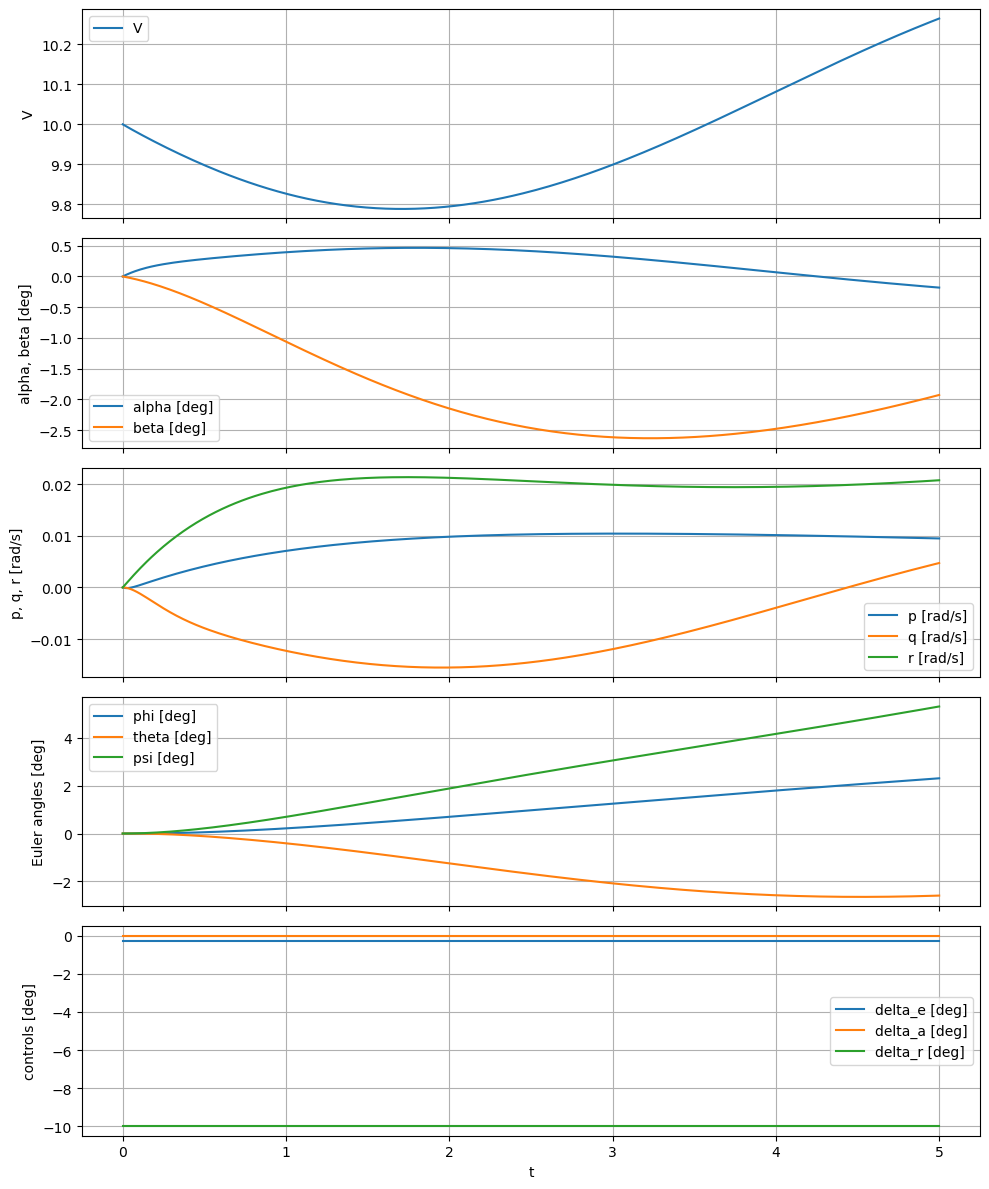

csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\rudder_step_response\rudder_step_6dof_history.csv
plot_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\results\rudder_step_response\rudder_step_6dof_history.png


In [5]:
csv_path = write_6dof_history_csv(
    history,
    output_dir / "rudder_step_6dof_history.csv",
)

plot_path = (
    output_dir
    / "rudder_step_6dof_history.png"
)
plot_6dof_history(
    history,
    plot_path=plot_path,
    show=True,
    degrees=True,
)

print("csv_path:", csv_path)
print("plot_path:", plot_path)


## 6. 確認事項

- `sixdof_roll_response_reached=True`
- `sixdof_roll_response_error`が空文字
- `V`と`Bref`が`.stab`の値と一致
- ラダー舵角と目標バンク角の符号が意図どおり
- 質量・慣性モーメントが対象機の単位系と一致
- 目標へ到達しない場合は、目標角、入力舵角、積分時間を物理的根拠に基づいて見直す
